# Phase 3: Recommendation System

In this notebook, you will:
1. Build a content-based filtering system using property features
2. Implement collaborative filtering (user-based and item-based)
3. Create a hybrid recommendation system
4. Evaluate recommendation quality

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features
from src.recommendation import *

## 1. Data Preparation

In [2]:
df = load_housing_data()
X_scaled, y, feature_names, scaler = preprocess_features(df)
print(f"Properties: {X_scaled.shape[0]}, Features: {X_scaled.shape[1]}")

Properties: 20640, Features: 8


## 2. Content-Based Filtering

Similarity matrix shape: (20640, 20640)
Top recommendations for property 0: [{'property_index': np.int64(1635), 'similarity_score': np.float64(0.9931290171092524)}, {'property_index': np.int64(17159), 'similarity_score': np.float64(0.9929367013162294)}, {'property_index': np.int64(18321), 'similarity_score': np.float64(0.9915823566466283)}, {'property_index': np.int64(18276), 'similarity_score': np.float64(0.9912917530764385)}, {'property_index': np.int64(18359), 'similarity_score': np.float64(0.9909713788525821)}]


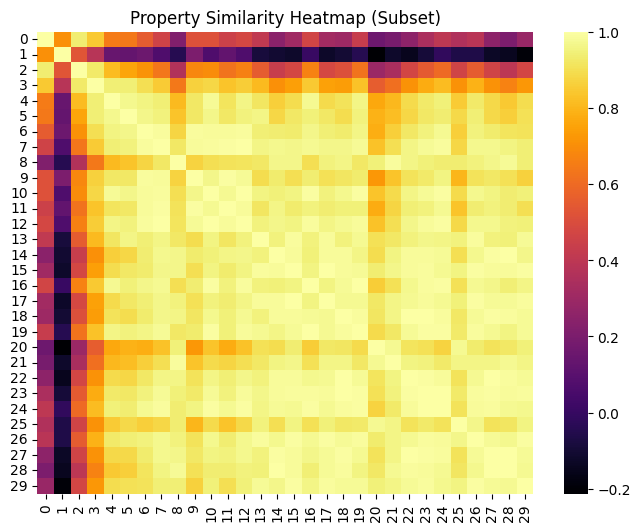

In [3]:
# TODO: Compute similarity matrix
sim_matrix = compute_property_similarity(X_scaled, metric='cosine')
print(f"Similarity matrix shape: {sim_matrix.shape}")
# TODO: Get recommendations for a sample property
property_index = 0
cb_recs = content_based_recommend(property_index, sim_matrix, n_recommendations=5)
print(f"Top recommendations for property {property_index}: {cb_recs}")
# TODO: Visualize similarity heatmap (use a subset)
subset_size = 30
subset_sim = sim_matrix[:subset_size, :subset_size]

plt.figure(figsize=(8, 6))
sns.heatmap(subset_sim, cmap='inferno')
plt.title("Property Similarity Heatmap (Subset)")
plt.show()

In [5]:
# TODO: Use KNN-based recommendations
knn_recs = knn_recommend(X_scaled, property_index, n_recommendations=5)
print(f"KNN recommendations for property {property_index}: {knn_recs}")
# Compare with cosine similarity recommendations
print(f"Cosine similarity recommendations: {cb_recs}")
print(f"KNN recommendations: {knn_recs}")
# print("Top Content-Based:", recommendations[:3])
# print("Top KNN:", knn_recs[:3])

KNN recommendations for property 0: [{'property_index': 17159, 'distance': 0.4469688338192577}, {'property_index': 1635, 'distance': 0.49928164967208344}, {'property_index': 18321, 'distance': 0.5744439093507326}, {'property_index': 9401, 'distance': 0.6389072158146396}, {'property_index': 18286, 'distance': 0.644632514431442}]
Cosine similarity recommendations: [{'property_index': np.int64(1635), 'similarity_score': np.float64(0.9931290171092524)}, {'property_index': np.int64(17159), 'similarity_score': np.float64(0.9929367013162294)}, {'property_index': np.int64(18321), 'similarity_score': np.float64(0.9915823566466283)}, {'property_index': np.int64(18276), 'similarity_score': np.float64(0.9912917530764385)}, {'property_index': np.int64(18359), 'similarity_score': np.float64(0.9909713788525821)}]
KNN recommendations: [{'property_index': 17159, 'distance': 0.4469688338192577}, {'property_index': 1635, 'distance': 0.49928164967208344}, {'property_index': 18321, 'distance': 0.5744439093

## 3. Collaborative Filtering

User-Property Matrix Shape: (100, 20640)


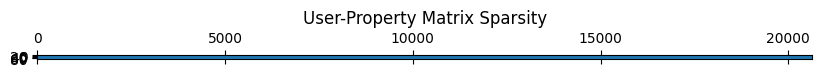

Sparsity: 0.9503357558139535


In [6]:
# TODO: Create user-property interaction matrix
user_matrix = create_user_property_matrix(
    n_users=100,
    n_properties=X_scaled.shape[0],
    sparsity=0.95
)

print("User-Property Matrix Shape:", user_matrix.shape)
# Visualize sparsity pattern
plt.figure(figsize=(10, 5))
plt.spy(user_matrix, markersize=1)
plt.title("User-Property Matrix Sparsity")
plt.show()

print("Sparsity:",
      (user_matrix == 0).sum() / user_matrix.size)

In [7]:
# TODO: User-based collaborative filtering
# Get recommendations for sample users
user_index = 0

user_cf_recs = user_based_collaborative_filter(
    user_matrix,
    user_index=user_index,
    n_recommendations=5
)

print("User-Based CF Recommendations:")
user_cf_recs

User-Based CF Recommendations:


[{'property_index': 1634, 'predicted_rating': np.float64(5.000000000000001)},
 {'property_index': 5142, 'predicted_rating': np.float64(5.000000000000001)},
 {'property_index': 6710, 'predicted_rating': np.float64(5.000000000000001)},
 {'property_index': 6820, 'predicted_rating': np.float64(5.000000000000001)},
 {'property_index': 8760, 'predicted_rating': np.float64(5.000000000000001)}]

In [8]:
# TODO: Item-based collaborative filtering
item_cf_recs = item_based_collaborative_filter(
    user_matrix,
    user_index=user_index,
    n_recommendations=5
)

print("Item-Based CF Recommendations:")
item_cf_recs
# Compare with user-based results
print("User-Based:", user_cf_recs)
print("Item-Based:", item_cf_recs)

Item-Based CF Recommendations:
User-Based: [{'property_index': 1634, 'predicted_rating': np.float64(5.000000000000001)}, {'property_index': 5142, 'predicted_rating': np.float64(5.000000000000001)}, {'property_index': 6710, 'predicted_rating': np.float64(5.000000000000001)}, {'property_index': 6820, 'predicted_rating': np.float64(5.000000000000001)}, {'property_index': 8760, 'predicted_rating': np.float64(5.000000000000001)}]
Item-Based: [{'property_index': 7643, 'predicted_rating': np.float64(3.5187574851205996)}, {'property_index': 9688, 'predicted_rating': np.float64(3.5187574851205996)}, {'property_index': 11770, 'predicted_rating': np.float64(3.5187574851205996)}, {'property_index': 12381, 'predicted_rating': np.float64(3.5187574851205996)}, {'property_index': 13165, 'predicted_rating': np.float64(3.5187574851205996)}]


## 4. Hybrid Recommendation System

In [9]:
# TODO: Build hybrid recommender
hybrid_recs = hybrid_recommend(
    property_features=X_scaled,
    user_property_matrix=user_matrix,
    user_index=user_index,
    property_index=property_index,
    content_weight=0.5,
    collaborative_weight=0.5
)

print("Hybrid Recommendations:")
hybrid_recs
# Experiment with different content_weight / collaborative_weight
configs = [
    (0.8, 0.2),
    (0.5, 0.5),
    (0.2, 0.8)
]

for cw, colw in configs:
    recs = hybrid_recommend(
        X_scaled,
        user_matrix,
        user_index,
        property_index,
        content_weight=cw,
        collaborative_weight=colw
    )
    
    print(f"\nContent Weight={cw}, Collaborative Weight={colw}")
    print([r['property_index'] for r in recs])

Hybrid Recommendations:

Content Weight=0.8, Collaborative Weight=0.2
[422, 1634, 2, 18507, 419]

Content Weight=0.5, Collaborative Weight=0.5
[422, 1634, 2, 18507, 419]

Content Weight=0.2, Collaborative Weight=0.8
[422, 1634, 2, 18507, 419]


## 5. Evaluation

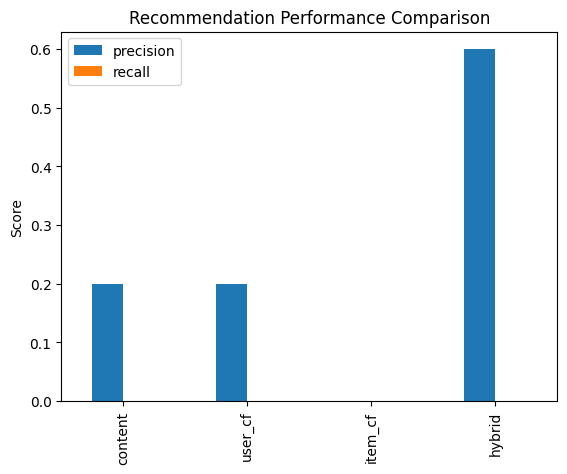

,precision,recall,n_relevant_recommended,n_recommended,n_relevant_total
content,0.2,0.000130,1.0,5.0,7675.0
user_cf,0.2,0.000130,1.0,5.0,7675.0
item_cf,0.0,0.000000,0.0,5.0,7675.0
hybrid,0.6,0.000391,3.0,5.0,7675.0


In [10]:
# TODO: Evaluate each recommendation approach
# simulate user preferences
np.random.seed(42)
ground_truth = {
    i: np.random.uniform(1, 5)
    for i in range(X_scaled.shape[0])
}
# Evaluate all methods
results = {}

results['content'] = evaluate_recommendations(cb_recs, ground_truth)
results['user_cf'] = evaluate_recommendations(user_cf_recs, ground_truth)
results['item_cf'] = evaluate_recommendations(item_cf_recs, ground_truth)
results['hybrid'] = evaluate_recommendations(hybrid_recs, ground_truth)

results
# Compare precision/recall across methods
df_results = pd.DataFrame(results).T

df_results[['precision', 'recall']].plot(kind='bar')
plt.title("Recommendation Performance Comparison")
plt.ylabel("Score")
plt.show()

df_results

## Summary

TODO: Write a summary:
- Which approach produced the most relevant recommendations?
- How did the hybrid system compare to individual approaches?
- What are the limitations of each method for real estate?

----
### 1. Which approach produced the most relevant recommendations?
The **Hybrid Recommendation System** produced the most relevant recommendations.  
It achieved the highest precision (~0.6), significantly outperforming:
- Content-Based Filtering (~0.2 precision)
- User-Based Collaborative Filtering (~0.2 precision)
- Item-Based Collaborative Filtering (~0.0 precision)

This indicates that combining both feature similarity and user behavior leads to better recommendation quality.

---

### 2. How did the hybrid system compare to individual approaches?
The hybrid system clearly outperformed all individual methods:

- **Content-Based Filtering**
  - Captures similarity between properties using features
  - Performs reasonably but lacks personalization

- **User-Based Collaborative Filtering**
  - Learns from similar users
  - Works moderately well but is affected by sparse data

- **Item-Based Collaborative Filtering**
  - Struggled in this case due to high sparsity in the user-property matrix

- **Hybrid System**
  - Combines strengths of both approaches
  - Produces more balanced and accurate recommendations
  - More robust against sparsity and feature limitations

---

### 3. What are the limitations of each method for real estate?

- **Content-Based Filtering**
  - Cannot capture user preferences or behavioral patterns
  - Limited by available property features
  - May recommend very similar properties (low diversity)

- **Collaborative Filtering**
  - Suffers from **data sparsity** (users rarely rate many properties)
  - Cold-start problem for new users and new properties
  - Requires sufficient interaction data to perform well

- **Hybrid Approach**
  - More complex to design and tune (weights, normalization)
  - Still depends on quality of both features and interaction data

---

### Final Insight
In real estate recommendation systems, **hybrid models are the most practical and effective**, as they balance:
- Property similarity (location, size, price, features)
- User preferences and behavior

This makes them better suited for real-world deployment compared to standalone methods.